In [148]:
import numpy as np
from numpy.linalg import norm
from scipy import spatial
import matplotlib.pyplot as plt
import math

In [149]:
kv_recomp = np.load("./saved_kv/recompute.npy")
kv_reuse = np.load("./saved_kv/reuse.npy")
print(kv_recomp.shape, kv_reuse.shape)

(28, 2, 1, 4, 246, 128) (28, 2, 1, 4, 246, 128)


In [150]:
def cos_distance(vec1: np.ndarray, vec2: np.ndarray):
    return spatial.distance.cosine(vec1, vec2)

def l2_distance(vec1: np.ndarray, vec2: np.ndarray):
    return norm(vec1-vec2)

In [151]:
def calculate_angle(x1, y1, x2, y2):
    vector1 = (x1, y1)
    vector2 = (x2, y2)
    dot_product = vector1[0] * vector2[0] + vector1[1] * vector2[1]
    magnitude1 = math.sqrt(vector1[0]**2 + vector1[1]**2)
    magnitude2 = math.sqrt(vector2[0]**2 + vector2[1]**2)
    if magnitude1 == 0 or magnitude2 == 0:
        return 0.0
    cos_angle = dot_product / (magnitude1 * magnitude2)
    cos_angle = max(min(cos_angle, 1.0), -1.0)
    angle_rad = math.acos(cos_angle)
    # angle_deg = math.degrees(angle_rad)
    return angle_rad

In [152]:
def calc_kv_distance(kv1, kv2, layer, korv, seq, head, metric):
    kv1 = kv1[layer, korv, seq, head]
    kv2 = kv2[layer, korv, seq, head]
    pos = 40
    hidden = 10
    half_head_size = kv1.shape[-1] // 2
    # half_head_size = 1
    x1, y1 = kv1[pos][hidden], kv1[pos][hidden + half_head_size]
    x2, y2 = kv2[pos][hidden], kv2[pos][hidden + half_head_size]
    delta = calculate_angle(x1, y1, x2, y2)
    # print(x1, y1, x2, y2)
    # print(f"delta: {delta}")
    # print((33 / (5000000.0 ** (hidden / half_head_size)) - delta) / np.pi)
    dis = np.zeros((kv2.shape[0],))
    for i, (vec1, vec2) in enumerate(zip(kv1, kv2)):
        dis[i] = metric(vec1, vec2)
    return dis

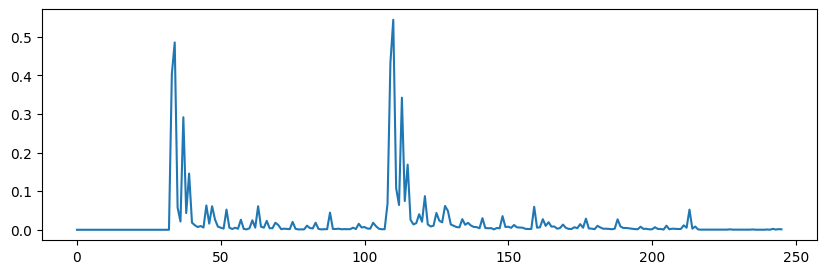

In [153]:
dis = calc_kv_distance(kv_recomp, kv_reuse, 2, 1, 0, 0, cos_distance)
plt.figure(figsize=(10,3))
plt.plot(dis)
plt.show()

seq_len 246


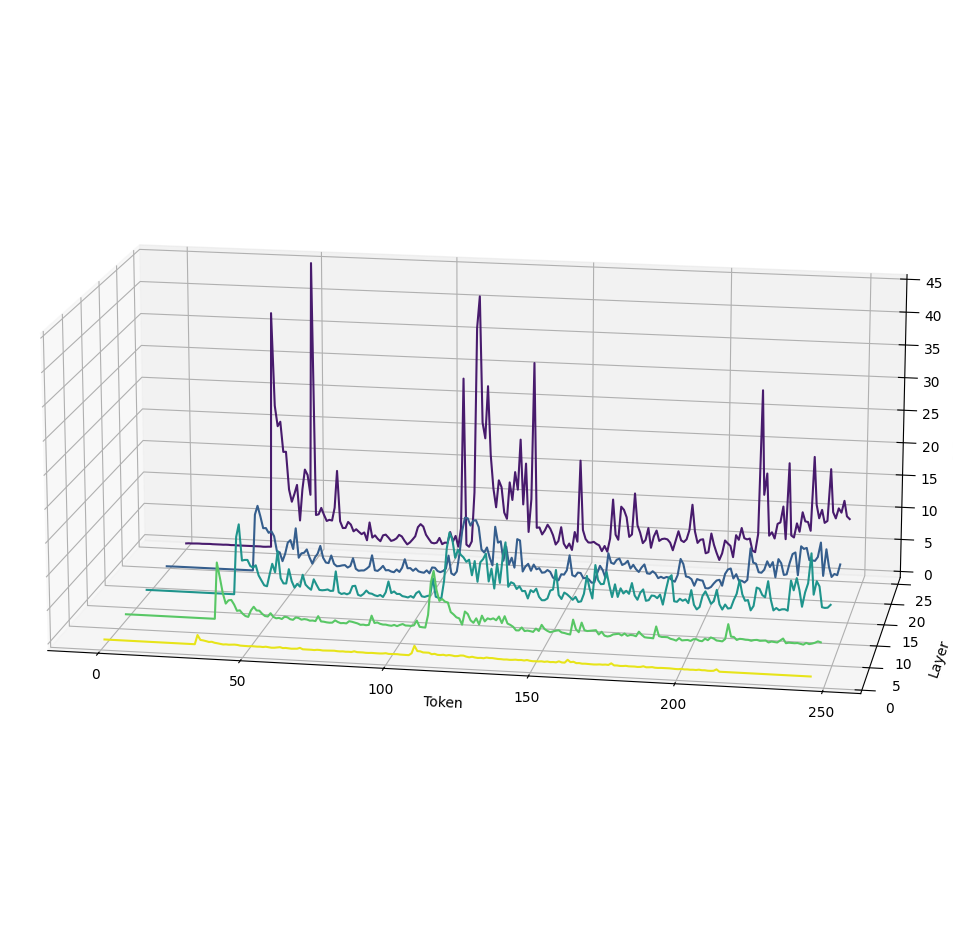

In [157]:
ax = plt.figure(figsize=(20,12)).add_subplot(projection='3d')
ax.set_box_aspect((40, 20, 16))
ax.view_init(elev=15, azim=-80, roll=0)
colors = plt.colormaps['viridis_r'](np.linspace(0, 1, kv_recomp.shape[0]))

seq_len = kv_recomp.shape[4]
x_indices = list(range(seq_len))
print("seq_len", seq_len)
for layer_i in reversed(range(1, kv_recomp.shape[0], 6)):
    ax.plot(
        x_indices, 
        [layer_i] * seq_len, 
        calc_kv_distance(kv_recomp, kv_reuse, layer_i, 1, 0, 1, l2_distance),
        color=colors[layer_i],
    )

ax.set(xlabel='Token', ylabel='Layer', zlabel='L2 Difference')

plt.show()